# Sector momentum: ranking, trend and the first return owned

**Constructed educational paths; no market backtest.** Three sectors pass both the twelve-month market comparison and positive-trend gate. Their equal-weight basket earns 2.33% in the illustrated holding interval before costs; the intervening pre-execution move is excluded.

[Chapter narrative](README.md) · [Research collection](../../README.md)

## Goal

Separate relative sector leadership, an absolute trend condition, and implementable ownership timing. The original repository topic was `05_sector_rotation_with_momentum.ipynb`. Its stated benchmark gate is made explicit here; the positive-trend gate is an additional teaching choice.

## Setup

Six fictional sectors and a fictional broad market begin at 100. Thirteen monthly closes identify a twelve-month return; two further closes expose the trade lag. “Month” labels are scenario steps, not calendar observations. No missing prices are filled, no dividends are estimated, and no historical ETF identities are implied.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from IPython.display import display

plt.rcParams.update({
    'figure.figsize': (10, 4.6), 'font.size': 11,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.18,
    'axes.axisbelow': True, 'figure.dpi': 120,
})
BLUE, GOLD, GRAY = '#245a81', '#bc8431', '#606975'
# All prices are constructed inside this notebook; there are no downloads.

In [2]:
annual_return = pd.Series({
    'Technology': 0.24, 'Industrials': 0.18, 'Financials': 0.12,
    'Utilities': 0.08, 'Staples': 0.03, 'Energy': -0.05,
    'Market': 0.10,
})
months = np.arange(13)
prices = pd.DataFrame(
    100 * (1 + annual_return.to_numpy())[None, :] ** (months[:, None] / 12),
    index=pd.Index(months, name='Constructed month'), columns=annual_return.index,
)
pre_execution_move = pd.Series(
    [-0.15, 0.02, 0.01, 0, 0, 0.02, -0.04], index=prices.columns
)
holding_return = pd.Series(
    [0.05, -0.01, 0.03, 0.005, 0.004, -0.02, 0.01], index=prices.columns
)
prices.loc[13] = prices.loc[12] * (1 + pre_execution_move)
prices.loc[14] = prices.loc[13] * (1 + holding_return)
sectors = list(prices.columns.drop('Market'))
display(prices.loc[[0, 12, 13, 14]].round(2))

,Technology,Industrials,Financials,Utilities,Staples,Energy,Market
Constructed month,,,,,,,
0,100.00,100.00,100.00,100.00,100.00,100.00,100.00
12,124.00,118.00,112.00,108.00,103.00,95.00,110.00
13,105.40,120.36,113.12,108.00,103.00,96.90,105.60
14,110.67,119.16,116.51,108.54,103.41,94.96,106.66


## Steps

### 1. Rank only information available at the signal close

Select up to five sectors with $P_t/P_{t-12}-1>\max(0,m_{market,t})$. The full risky budget is divided over the qualifying names; zero qualifiers means 100% cash. Stable alphabetical ordering resolves exact score ties.

In [3]:
def sector_signal(path, information_month, maximum_holdings=5):
    history = path.loc[:information_month]
    if len(history) < 13 or history.isna().any().any():
        raise ValueError('Need thirteen complete monthly closes.')
    if not np.isfinite(history.to_numpy()).all() or (history <= 0).any().any():
        raise ValueError('Prices must be finite and positive.')
    score = history.iloc[-1] / history.iloc[-13] - 1
    ranked = score.loc[sectors].sort_index().sort_values(ascending=False, kind='stable')
    selected = ranked[ranked > max(0.0, score['Market'])].head(maximum_holdings)
    weights = pd.Series(0.0, index=sectors + ['Cash'])
    if len(selected):
        weights.loc[selected.index] = 1 / len(selected)
    else:
        weights.loc['Cash'] = 1.0
    return score, weights

score, weights = sector_signal(prices, 12)
ranking = pd.DataFrame({
    'Twelve-month return': score.loc[sectors],
    'Beats market': score.loc[sectors] > score['Market'],
    'Positive trend': score.loc[sectors] > 0,
    'Target weight': weights.loc[sectors],
}).sort_values('Twelve-month return', ascending=False)
display(ranking.style.format({'Twelve-month return': '{:.1%}', 'Target weight': '{:.1%}'}))

,Twelve-month return,Beats market,Positive trend,Target weight
Technology,24.0%,True,True,33.3%
Industrials,18.0%,True,True,33.3%
Financials,12.0%,True,True,33.3%
Utilities,8.0%,False,True,0.0%
Staples,3.0%,False,True,0.0%
Energy,-5.0%,False,False,0.0%


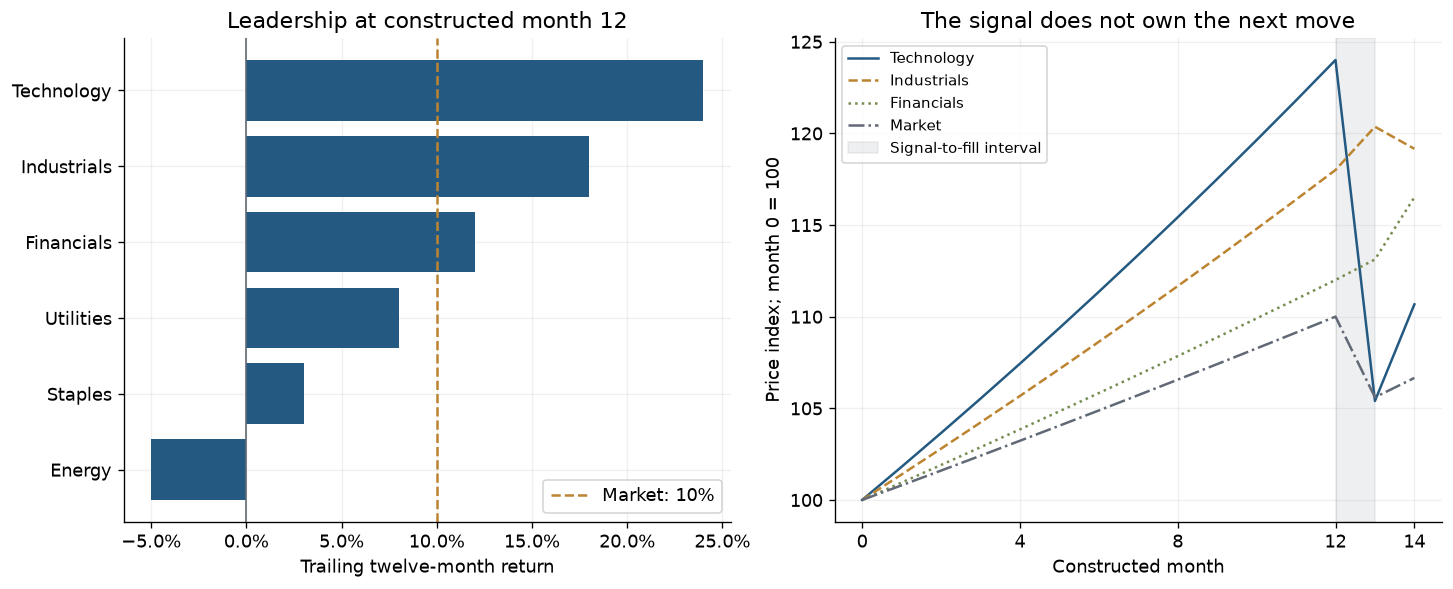

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), layout='constrained')
ranked = ranking['Twelve-month return'].sort_values()
axes[0].barh(ranked.index, ranked, color=BLUE)
axes[0].axvline(0, color=GRAY, linewidth=1)
axes[0].axvline(score['Market'], color=GOLD, linestyle='--', label='Market: 10%')
axes[0].xaxis.set_major_formatter(PercentFormatter(1))
axes[0].set(title='Leadership at constructed month 12', xlabel='Trailing twelve-month return')
axes[0].legend(loc='lower right')
for name, style, color in [('Technology', '-', BLUE), ('Industrials', '--', GOLD),
                           ('Financials', ':', '#768c51'), ('Market', '-.', GRAY)]:
    axes[1].plot(prices.index, prices[name], linestyle=style, color=color, label=name)
axes[1].axvspan(12, 13, color=GRAY, alpha=0.10, label='Signal-to-fill interval')
axes[1].set(xticks=[0, 4, 8, 12, 14], xlabel='Constructed month', ylabel='Price index; month 0 = 100',
            title='The signal does not own the next move')
axes[1].legend(fontsize=9, loc='upper left')
plt.show()

### 2. Ask whether the same ranking survives a falling market

Lower every month-12 endpoint by 30%, preserving relative rank. A market comparison alone can still select leaders, but this chapter's positive-trend condition moves the portfolio to cash. This is a controlled change in inputs, not an observed crisis.

In [5]:
stressed_prices = prices.copy()
stressed_prices.loc[12] *= 0.70
stressed_score, stressed_weights = sector_signal(stressed_prices, 12)
relative_winners = stressed_score.loc[sectors] > stressed_score['Market']
display(pd.DataFrame({
    'Stressed twelve-month return': stressed_score.loc[sectors],
    'Beats falling market': relative_winners,
    'Weight with positive-trend gate': stressed_weights.loc[sectors],
}).round(4))
print(f'Cash weight with the gate: {stressed_weights["Cash"]:.0%}')

,Stressed twelve-month return,Beats falling market,Weight with positive-trend gate
Technology,-0.132,True,0.0
Industrials,-0.174,True,0.0
Financials,-0.216,True,0.0
Utilities,-0.244,False,0.0
Staples,-0.279,False,0.0
Energy,-0.335,False,0.0


Cash weight with the gate: 100%


### 3. Assign returns after execution and account for costs

The month-12 information set is available only after that close. This coarse monthly example deliberately waits until month 13 to execute, then earns the return ending at month 14. It does not model next-day execution. With initial capital 100 and a cost rate $c$, invested notional is $100/(1+c)$; liquidation returns that notional times the basket gross factor and $(1-c)$.

In [6]:
signal_month, execution_month, return_end_month = 12, 13, 14
realized = prices.loc[return_end_month, sectors] / prices.loc[execution_month, sectors] - 1
gross_return = float(weights.loc[sectors] @ realized)
rate = 0.0005
invested = 100 / (1 + rate)
units = invested * weights.loc[sectors] / prices.loc[execution_month, sectors]
liquidation_notional = float(units @ prices.loc[return_end_month, sectors])
terminal_wealth = liquidation_notional * (1 - rate)
display(pd.DataFrame([{
    'Information month': signal_month, 'Execution month': execution_month,
    'First return end': return_end_month, 'Gross basket return': gross_return,
    'Terminal wealth after two-sided costs': terminal_wealth,
}]).round(6))

,Information month,Execution month,First return end,Gross basket return,Terminal wealth after two-sided costs
0,12,13,14,0.023333,102.231051


## Checks

In [7]:
assert set(weights[weights > 0].index) == {'Technology', 'Industrials', 'Financials'}
np.testing.assert_allclose(weights.sum(), 1)
np.testing.assert_allclose(gross_return, (0.05 - 0.01 + 0.03) / 3)
np.testing.assert_allclose(terminal_wealth, 100 * (1 + gross_return) * (1 - rate) / (1 + rate))
assert relative_winners.any() and stressed_weights['Cash'] == 1
changed_future = prices.copy()
changed_future.loc[13:] *= np.array([2, 0.5, 3, 0.4, 1.7, 2.2, 0.8])
pd.testing.assert_series_equal(sector_signal(changed_future, 12)[1], weights)
assert signal_month < execution_month < return_end_month
print('Passed: ranking, budget, stressed-market gate, independent cash-flow calculation, and timing.')

Passed: ranking, budget, stressed-market gate, independent cash-flow calculation, and timing.


## Next steps

The constructed result explains ownership and filters; it estimates no expected return. A historical study should compare the ungated rank strategy, benchmark gate and added absolute gate under the same universe, costs and rebalance dates. Report concentration, turnover, market beta and missed recoveries alongside return. The original author’s sector rotation topic is retained here as a design exercise; no original performance chart is carried forward.

[Continue to the reversal chapter](../09-sector-reversal/README.md).